In [ ]:
import os
from sqlalchemy import create_engine
db_url = (
    f"postgresql://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"localhost:5432/"
    f"{os.getenv('POSTGRES_DB')}"
)

engine = create_engine(db_url)

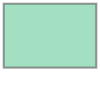

In [10]:
import geopandas as gpd
query = """SELECT * FROM raw_table WHERE fetched_city = 'Padova'"""
raw_gdf = gpd.GeoDataFrame.from_postgis(query, engine,geom_col='geometry')
extent = (raw_gdf["geometry"].union_all())
minx, miny, maxx, maxy = extent.bounds

from shapely.geometry import box
enclosing_poly = box(minx, miny, maxx, maxy)
enclosing_poly

In [ ]:
from shapely.geometry import box
import geopandas as gpd
import pandas as pd
import numpy as np

def subdivide_polygon(polygon, n_tiles):
    minx, miny, maxx, maxy = polygon.bounds
    
    n_cols = int(np.ceil(np.sqrt(n_tiles)))
    n_rows = int(np.ceil(n_tiles / n_cols))
    
    x_splits = np.linspace(minx, maxx, n_cols + 1)
    y_splits = np.linspace(miny, maxy, n_rows + 1)
    
    tiles = []
    for i in range(n_cols):
        for j in range(n_rows):
            tile = box(x_splits[i], y_splits[j],
                       x_splits[i+1], y_splits[j+1])
            
            clipped = polygon.intersection(tile)
            if not clipped.is_empty:
                tiles.append(clipped)
    
    return tiles[:n_tiles]


In [17]:
import osmnx as ox
num_tiles = 2
tiles = subdivide_polygon(extent, num_tiles)

data_geometries_list = []
for i, tile in enumerate(tiles):
    print(f"Fetching tile {i+1}/{len(tiles)}")
    data_geometries_tile = ox.geometries_from_polygon(enclosing_poly, tags =  {'landuse': True, 'building': True, 'amenity': True, 'leisure': True,
                'shop': True, 'office': True, 'sport': True, 'tourism': True}
)
    data_geometries_list.append(data_geometries_tile)

# data_geometries = ox.geometries_from_polygon(extent, tags) #deprecated and will be removed in the future
#data_geometries = ox.features_from_polygon(extent, tags) #osmnx version 1.6.0
data_geometries = gpd.GeoDataFrame(pd.concat(data_geometries_list))

Fetching tile 1/2


/tmp/ipykernel_1566323/2453064424.py:8: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  data_geometries_tile = ox.geometries_from_polygon(enclosing_poly, tags =  {'landuse': True, 'building': True, 'amenity': True, 'leisure': True,


Fetching tile 2/2


/tmp/ipykernel_1566323/2453064424.py:8: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  data_geometries_tile = ox.geometries_from_polygon(enclosing_poly, tags =  {'landuse': True, 'building': True, 'amenity': True, 'leisure': True,


In [18]:
data_geometries

amenity         brand brand:wikidata  \
element_type osmid                                                      
node         215541278              fuel       Q8 Easy       Q1806948   
             215541291              fuel  Esso Express       Q2350336   
             215543602              fuel            IP       Q3788748   
             215550122              fuel       Enilive     Q125246327   
             215823249              fuel           NaN            NaN   
...                                  ...           ...            ...   
relation     20391561                NaN           NaN            NaN   
             20391562   place_of_worship           NaN            NaN   
             20391563                NaN           NaN            NaN   
             20391564                NaN           NaN            NaN   
             20391565                NaN           NaN            NaN   

                       fuel:diesel fuel:octane_95            name  \
element_type osmid                                                  
node         215541278         yes            yes  Q8 Easy Stanga   
             215541291         NaN            NaN    Esso Express   
             215543602         yes            yes              IP   
             215550122         yes            yes         Enilive   
             215823249         yes            yes         IPlanet   
...                            ...            ...             ...   
relation     20391561          NaN            NaN             NaN   
             20391562          NaN            NaN  San Prosdocimo   
             20391563          NaN            NaN             NaN   
             20391564          NaN            NaN             NaN   
             20391565          NaN            NaN             NaN   

                                                       operator ref:mise  \
element_type osmid                                                         
node         215541278         Servizi & Gestioni Italia S.R.L.    20039   
             215541291  G.I.Car. S.A.S. di Bergamin Nicola & C.    27813   
             215543602                       Bassanello Tiziano    16112   
             215550122                                      Eni    27505   
             215823249                                      NaN     5534   
...                                                         ...      ...   
relation     20391561                                       NaN      NaN   
             20391562                                       NaN      NaN   
             20391563                                       NaN      NaN   
             20391564                                       NaN      NaN   
             20391565                                       NaN      NaN   

                                                     source  \
element_type osmid                                            
node         215541278  MISE - Ministero Sviluppo Economico   
             215541291                                  NaN   
             215543602  MISE - Ministero Sviluppo Economico   
             215550122  MISE - Ministero Sviluppo Economico   
             215823249  MISE - Ministero Sviluppo Economico   
...                                                     ...   
relation     20391561                                   NaN   
             20391562                                   NaN   
             20391563                                   NaN   
             20391564                                   NaN   
             20391565                                   NaN   

                                                                 geometry  \
element_type osmid                                                          
node         215541278                          POINT (11.90306 45.40881)   
             215541291                           POINT (11.9072 45.41029)   
             215543602                          POINT (11.89933 45.3

In [16]:
data_geometries

,amenity,brand,brand:wikidata,fuel:diesel,fuel:octane_95,name,operator,ref:mise,source,geometry,...,tower:construction,ways,community,community:en,community:fr,community:gender,community:it,monastery:type,architect:wikidata,priority
0,fuel,Q8 Easy,Q1806948,yes,yes,Q8 Easy Stanga,Servizi & Gestioni Italia S.R.L.,20039,MISE - Ministero Sviluppo Economico,POINT (11.90306 45.40881),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,fuel,Esso Express,Q2350336,NaN,NaN,Esso Express,G.I.Car. S.A.S. di Bergamin Nicola & C.,27813,NaN,POINT (11.9072 45.41029),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,fuel,IP,Q3788748,yes,yes,IP,Bassanello Tiziano,16112,MISE - Ministero Sviluppo Economico,POINT (11.89933 45.39715),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,fuel,Enilive,Q125246327,yes,yes,Enilive,Eni,27505,MISE - Ministero Sviluppo Economico,POINT (11.88856 45.40075),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,fuel,NaN,NaN,yes,yes,IPlanet,NaN,5534,MISE - Ministero Sviluppo Economico,POINT (11.88808 45.39635),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((11.88584 45.4003, 11.88588 45.4003, ...",...,NaN,"[131987496, 1494319885]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
92812,place_of_worship,NaN,NaN,NaN,NaN,San Prosdocimo,NaN,NaN,NaN,"POLYGON ((11.88587 45.39999, 11.88581 45.4, 11...",...,NaN,"[131987740, 1494319886]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
92813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((11.88775 45.39931, 11.88775 45.39931...",...,NaN,"[1494319895, 1494319896, 131990698, 1494319899...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
92814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((11.88776 45.39929, 11.8878 45.3993, ...",...,NaN,"[131990922, 1494319898, 1494319888, 1494319893...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
